In [1]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


# Read the Data

In [2]:
import pandas as pd

df = pd.read_csv("Airline.csv")
df.head(2)


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,New Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0


In [3]:
#


# Handle the Null Values

In [4]:
df.isnull().sum()


ID                 0
Airline            0
Date_of_Journey    0
Source             2
Destination        2
Route              3
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              3
dtype: int64

In [5]:
# Handle Null Values from Price
# Drop or replace the null with mean/median

df[df['Price'].isnull()]
mean_Price = df["Price"].mean()
mean_Price
df.fillna({'Price':mean_Price},inplace=True)



,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,New Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,3,Jet Airways,09-06-2019,Delhi,Cochin,DEL _ LKO _ BOM _ COK,09:25,10-06-2026 04:25,19h,2 stops,No info,13882.0
3,4,IndiGo,12-05-2019,Kolkata,Banglore,CCU _ NAG _ BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,5,IndiGo,01-03-2019,Banglore,New Delhi,BLR _ NAG _ DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10684,10679,Air Asia,09-04-2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107.0
10685,10680,Air India,27-04-2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145.0
10686,10681,Jet Airways,27-04-2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229.0
10687,10682,Vistara,01-03-2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648.0


In [6]:
# Handle Missing Values of Source,Destinatoin and Stops 
# using mode(Most Frequent)
# Why are we using Mode? this is categoral columns
mode_Source = df['Source'].mode()[0]
mode_Source

df.fillna({'Source':mode_Source},inplace=True)

df[df['Source'].isnull()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [7]:
mode_Desti = df['Destination'].mode()[0]

df.fillna({'Destination':mode_Desti},inplace=True)
df[df['Destination'].isnull()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [8]:
df[df['Total_Stops'].isnull()]

mode_T_Stops =df['Total_Stops'].mode()[0]

df.fillna({'Total_Stops':mode_T_Stops},inplace=True)

df[df['Total_Stops'].isnull()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


# Remove the Duplicates

In [9]:
# Find and remove the Duplicates

df[df.duplicated()]

df.drop_duplicates(inplace=True)


In [10]:
df[df.duplicated()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [11]:
df.columns

for i in df.columns:
    print(i)


ID
Airline
Date_of_Journey
Source
Destination
Route
Dep_Time
Arrival_Time
Duration
Total_Stops
Additional_Info
Price


# Handle the Uneven Values

In [12]:
['Airline','Source','Destination','Total_Stops']


['Airline', 'Source', 'Destination', 'Total_Stops']

In [13]:
df['Airline'].unique()
df['Source'].unique()
df['Destination'].unique()
#df['Total_Stops'].unique()


<ArrowStringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [14]:
df['Airline'].value_counts()
df['Airline'] = df['Airline'].replace({'Multiple carriers Premium economy':'Multiple carriers'})
df['Airline'] = df['Airline'].replace({'Jet Airways Business':'Jet Airways'})
df['Airline'] = df['Airline'].replace({'Vistara Premium economy':'Vistara'})


df['Airline'].value_counts()


Airline
Jet Airways          3855
IndiGo               2053
Air India            1752
Multiple carriers    1209
SpiceJet              818
Vistara               482
Air Asia              319
GoAir                 194
Trujet                  1
Name: count, dtype: int64

In [15]:
df["Destination"] = df["Destination"].str.replace({'New Delhi':'Delhi'})


In [16]:
df['Destination'].unique()


<ArrowStringArray>
['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad']
Length: 5, dtype: str

In [17]:
df.head(2)


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0


In [18]:
# 



# Stat Based Analysis

In [19]:
df.describe()


,ID,Price
count,10683.000000,10683.000000
mean,5342.000000,9087.219176
std,3084.060797,4611.065933
min,1.000000,1759.000000
25%,2671.500000,5277.000000
50%,5342.000000,8372.000000
75%,8012.500000,12373.000000
max,10683.000000,79512.000000


# Graph Based Analysis

In [20]:
# install the liabraries
# pip install matplotlib
# pip install seaborn


In [21]:
# Import required Liabraries for Visualization

import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
Air_Index = df.groupby('Airline')['Airline'].count().sort_values().index
Air_Index



Index(['Trujet', 'GoAir', 'Air Asia', 'Vistara', 'SpiceJet',
       'Multiple carriers', 'Air India', 'IndiGo', 'Jet Airways'],
      dtype='str', name='Airline')

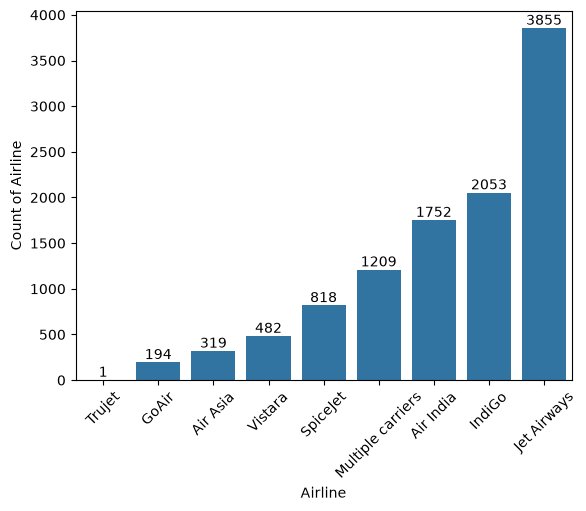

In [23]:
# Count distribution against Airline


ax = sns.countplot(x=df['Airline'],order=Air_Index)
plt.bar_label(ax.containers[0])
plt.xticks(rotation=45)
plt.ylabel('Count of Airline')
plt.show()


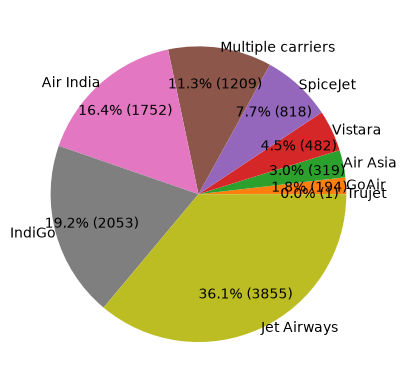

In [24]:
# Count distribution against Airline
def label_Add(df):
    def percentage(p):
        per = f'{p:.1f}%'
        value = f'{p * sum(df)/100:.0f}'
        return f'{per} ({value})'
    return percentage



Air_df = df.groupby('Airline')['Airline'].count().sort_values()
Air_df.reset_index
plt.pie(Air_df, labels=Air_df.index, autopct=label_Add(Air_df), labeldistance=1,  pctdistance=0.75   )
plt.show()


In [25]:
Source_Df_Count = df.groupby(['Source'])['Source'].count().sort_values()
Source_Df_Count


Source
Chennai      381
Mumbai       697
Banglore    2196
Kolkata     2871
Delhi       4538
Name: Source, dtype: int64

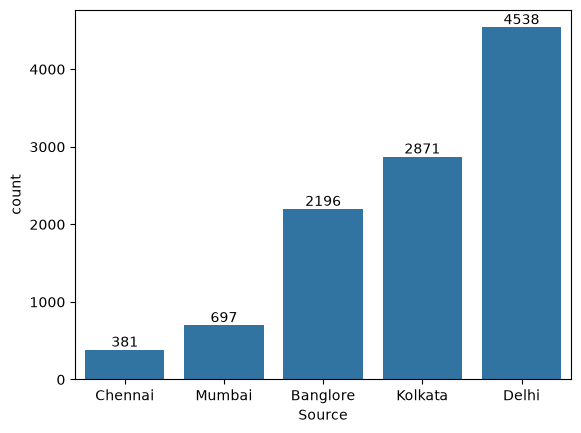

In [26]:
ax  = sns.countplot(x=df['Source'],order=Source_Df_Count.index)
ax.bar_label(ax.containers[0])
plt.show()


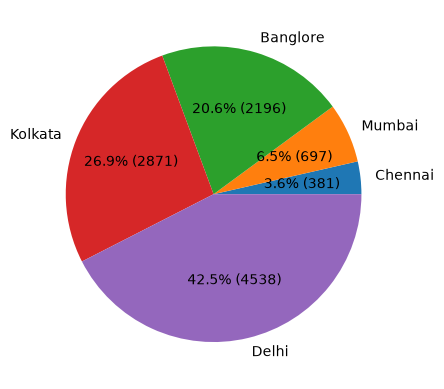

In [27]:
# Count distribution against Airline
def label_Add(df):
    def percentage(p):
        per = f'{p:.1f}%'
        value = f'{p * sum(df)/100:.0f}'
        return f'{per} ({value})'
    return percentage


plt.pie(Source_Df_Count,labels=Source_Df_Count.index,autopct=label_Add(Source_Df_Count))


In [28]:
Ttl_St_Counts = df.groupby('Total_Stops')['Total_Stops'].count().sort_values()

Ttl_St_Counts


Total_Stops
4 stops        1
3 stops       45
2 stops     1520
non-stop    3491
1 stop      5626
Name: Total_Stops, dtype: int64

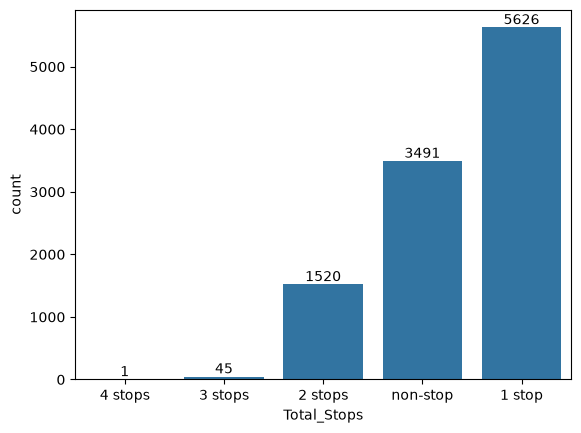

In [29]:
ax = sns.countplot(x=df['Total_Stops'],order=Ttl_St_Counts.index)
ax.bar_label(ax.containers[0])
plt.show()


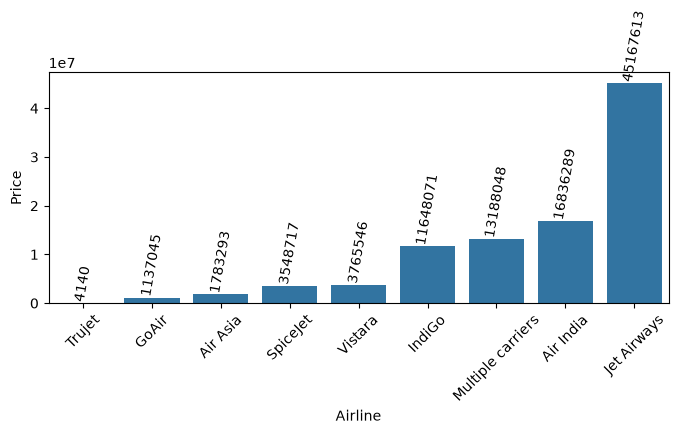

In [30]:
# Price Distribution(sale contibution) against 
df_Price_Air = df.groupby('Airline')['Price'].sum().sort_values()
df_Price_Air
plt.figure(figsize=(8,3))
ax = sns.barplot(x=df['Airline'],y=df['Price'],order=df_Price_Air.index,errorbar=None,estimator='sum')
ax.bar_label(ax.containers[0],rotation=80,fmt='%.0f')
plt.xticks(rotation=45)
plt.show()


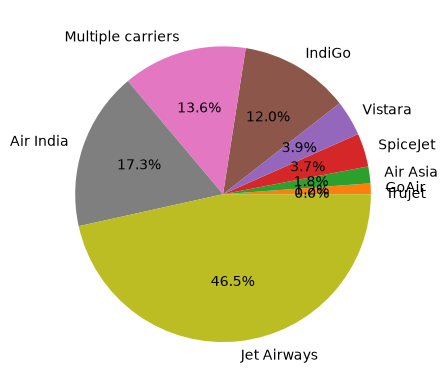

In [31]:
plt.pie(df_Price_Air,labels=df_Price_Air.index,autopct="%1.1f%%")
plt.savefig("Presentation/PieChart.png")
plt.show()


In [32]:
df_Sou_Price = df.groupby('Source')['Price'].sum().sort_values()
df_Sou_Price


Source
Chennai     1.824949e+06
Mumbai      3.526617e+06
Banglore    1.760949e+07
Kolkata     2.629047e+07
Delhi       4.782724e+07
Name: Price, dtype: float64

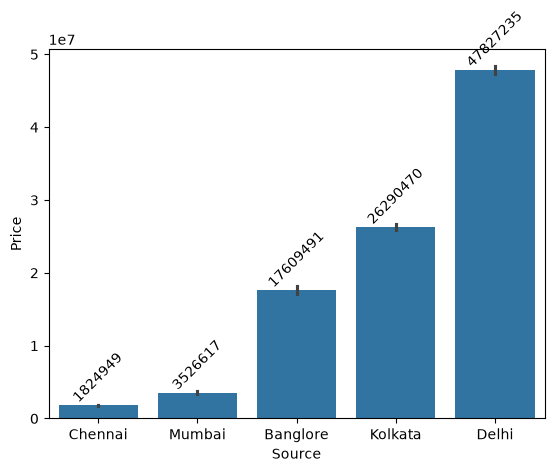

In [33]:
ax = sns.barplot(x=df['Source'],y=df['Price'],estimator='sum',order=df_Sou_Price.index)
ax.bar_label(ax.containers[0],rotation=45,fmt="%.0f")
plt.show()


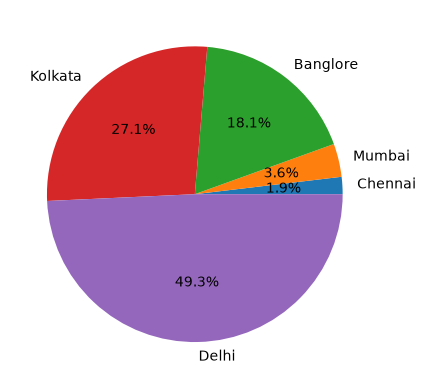

In [34]:
plt.pie(df_Sou_Price,labels=df_Sou_Price.index,autopct='%1.1f%%')
plt.show()


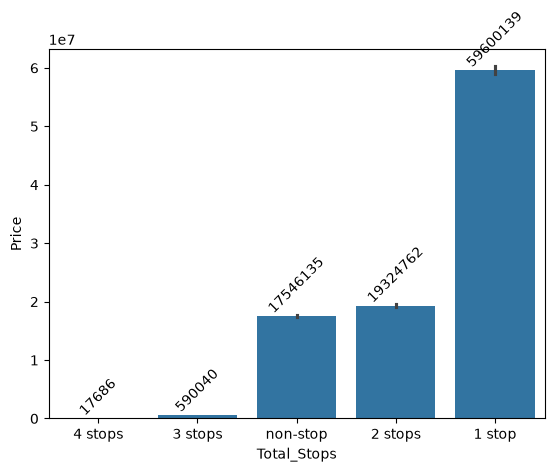

In [35]:
df_Total_Stops = df.groupby('Total_Stops')['Price'].sum().sort_values()
df_Total_Stops

ax = sns.barplot(x=df['Total_Stops'],y=df['Price'],estimator='sum',order=df_Total_Stops.index)
ax.bar_label(ax.containers[0],rotation=45,fmt="%.0f")
plt.show()


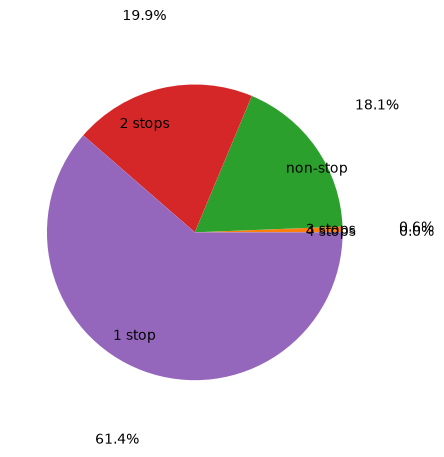

In [36]:

ax = plt.pie(df_Total_Stops,labels=df_Total_Stops.index,autopct="%1.1f%%",labeldistance=.75,  pctdistance=1.5  )
plt.savefig("airline_prices.png")
plt.show()



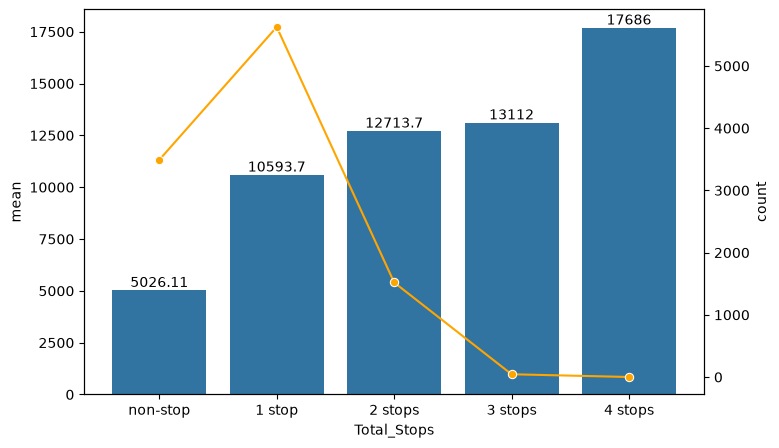

In [37]:
df_Stops = df.groupby(['Total_Stops'])["Price"].agg(['mean','count']).sort_values(by='mean')
df_Stops = df_Stops
df_Stops


plt.figure(figsize=(8,5))
ax1 = sns.barplot(df_Stops['mean'])
ax1.bar_label(ax1.containers[0])

ax2 = ax1.twinx()
ax2 = sns.lineplot(df_Stops['count'],color='orange',marker="o")
plt.show()


In [38]:
df['Sector'] = df['Source']+"_"+df['Destination']
newDF = df.groupby(['Total_Stops','Sector'])['Price'].mean()
newDF = newDF.reset_index()
newDF


,Total_Stops,Sector,Price
0,1 stop,Banglore_Delhi,14016.540925
1,1 stop,Delhi_Cochin,10030.246125
2,1 stop,Kolkata_Banglore,10477.414395
3,1 stop,Mumbai_Hyderabad,12520.477273
4,2 stops,Banglore_Delhi,13322.800000
5,2 stops,Delhi_Cochin,12752.039533
6,2 stops,Kolkata_Banglore,12025.311769
7,2 stops,Mumbai_Hyderabad,16696.266667
8,3 stops,Banglore_Delhi,12761.000000
9,3 stops,Delhi_Cochin,12939.840000


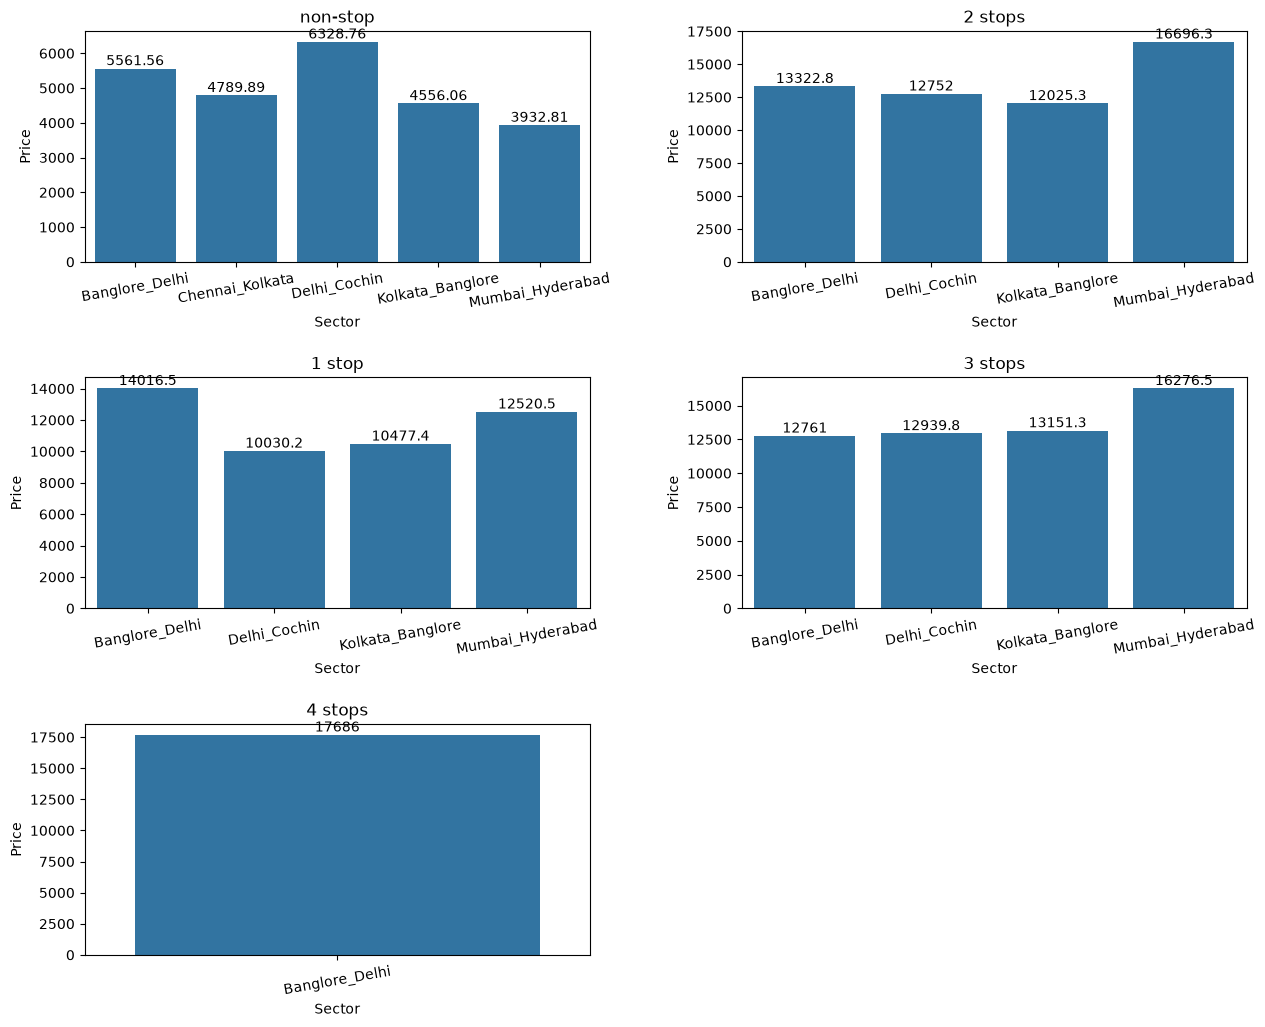

In [ ]:
stops = [df['Total_Stops'].unique()][0]

plt.figure(figsize=(15,12))
for k,v in enumerate(stops):
    Stops_Df = ""
    Stops_Df = newDF[newDF['Total_Stops']==v]
    plt.subplot(3,2,k+1)
    ax1 = sns.barplot(x=Stops_Df['Sector'],y=Stops_Df['Price'])
    ax1.bar_label(ax1.containers[0])
    plt.xticks(rotation=10)
    plt.title(v)

plt.subplots_adjust(
    wspace=0.3,   # horizontal space
    hspace=0.5    # vertical space
)
plt.show()


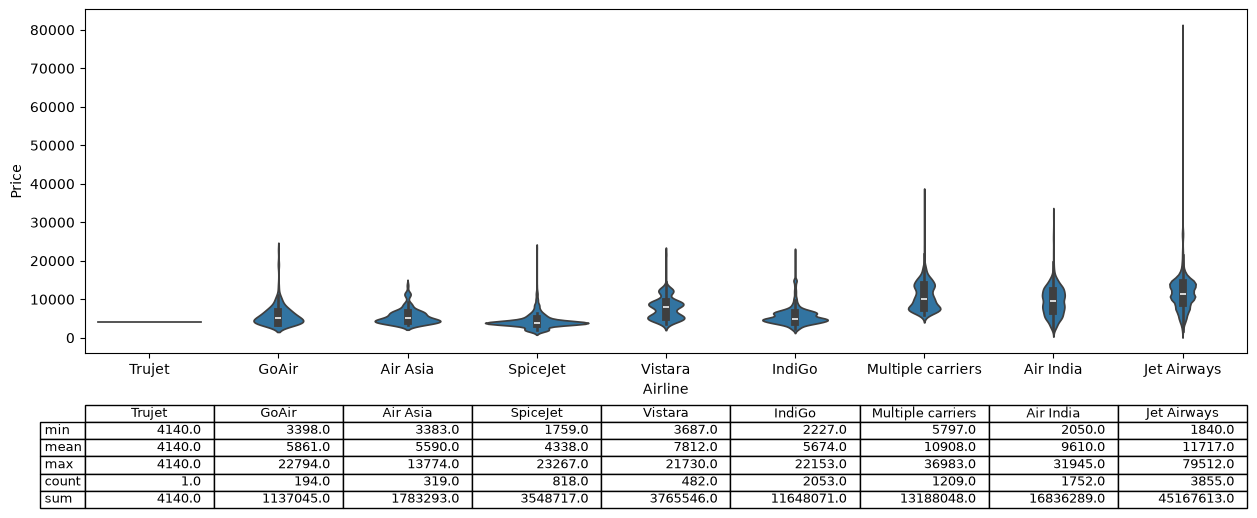

In [40]:
stats_01 = df.groupby('Airline')['Price'].agg(['min','mean','max','count','sum']).sort_values(by='sum')
stats = stats_01.round(0)
stats = stats.T
stats

plt.figure(figsize=(15,8))
ax = sns.violinplot(x=df['Airline'],y=df['Price'],order=stats.columns)

table = ax.table(
     cellText=stats.values,
     rowLabels=stats.index,
     colLabels=stats.columns,
     bbox=[0.0, -0.45, 1.0, 0.3])

table.auto_set_font_size(False)
table.set_fontsize(9)
plt.subplots_adjust(bottom=0.45)



plt.savefig("Presentation/1.Stats.png")
plt.show()
